# Day 32 | PM Session — Decision Trees & Random Forest: Applied
**Week 6 | IIT Gandhinagar — AI-ML & Agentic AI Engineering**

---

## Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings, time
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree, _tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, recall_score, precision_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
from scipy.stats import randint

np.random.seed(42)
print("All libraries loaded ✓")

All libraries loaded ✓


---
## Part A — Concept Application (40%)
### Insurance Claim Fraud Detection

### A.1 — Synthetic Insurance Claims Dataset (3000 records)

In [2]:
np.random.seed(42)
n = 3000

# Feature generation
claim_amount        = np.random.exponential(8000, n).clip(500, 80000)
policy_age_years    = np.random.uniform(0.5, 20, n)
num_prev_claims     = np.random.poisson(1.2, n).clip(0, 10)
annual_premium      = np.random.normal(1800, 600, n).clip(500, 5000)
days_to_report      = np.random.exponential(4, n).clip(0, 60).astype(int)
claimant_age        = np.random.normal(42, 14, n).clip(18, 85).astype(int)
num_witnesses       = np.random.randint(0, 5, n)
claim_to_premium    = claim_amount / annual_premium

# Rule-based fraud score
fraud_score = (
    0.30 * (claim_amount / 80000) +
    0.20 * (num_prev_claims / 10) +
    0.20 * (days_to_report / 60) +
    0.15 * (claim_to_premium / claim_to_premium.max()) +
    0.10 * (1 - policy_age_years / 20) +
    0.05 * (1 - num_witnesses / 4)
)
noise = np.random.normal(0, 0.06, n)
is_fraud = ((fraud_score + noise) > 0.38).astype(int)

df = pd.DataFrame({
    'claim_amount'     : claim_amount.round(2),
    'policy_age_years' : policy_age_years.round(2),
    'num_prev_claims'  : num_prev_claims,
    'annual_premium'   : annual_premium.round(2),
    'days_to_report'   : days_to_report,
    'claimant_age'     : claimant_age,
    'num_witnesses'    : num_witnesses,
    'claim_to_premium' : claim_to_premium.round(4),
    'is_fraud'         : is_fraud
})

print(f"Dataset shape  : {df.shape}")
print(f"Fraud rate     : {df['is_fraud'].mean():.1%}")
df.head()

Dataset shape  : (3000, 9)
Fraud rate     : 0.5%


,claim_amount,policy_age_years,num_prev_claims,annual_premium,days_to_report,claimant_age,num_witnesses,claim_to_premium,is_fraud
0,3754.14,13.62,1,2038.18,11,50,0,1.8419,0
1,24080.97,16.04,2,2064.09,0,63,1,11.6666,0
2,10533.97,5.38,2,1078.51,3,57,4,9.7671,0
3,7303.54,12.69,1,2699.57,2,43,3,2.7054,0
4,1357.00,11.65,4,1557.90,2,39,0,0.8710,0


In [3]:
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train fraud rate: {y_train.mean():.1%} | Test fraud rate: {y_test.mean():.1%}")

Train: (2400, 8) | Test: (600, 8)
Train fraud rate: 0.5% | Test fraud rate: 0.5%


### A.2 — Decision Tree (max_depth=5) + Top 3 Fraud Indicator Rules

In [4]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print("Decision Tree Metrics:")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"  Recall   : {recall_score(y_test, y_pred_dt):.4f}")
print(f"  F1       : {f1_score(y_test, y_pred_dt):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, y_prob_dt):.4f}")

Decision Tree Metrics:
  Accuracy : 0.9550
  Recall   : 0.6667
  F1       : 0.1290
  ROC-AUC  : 0.8116


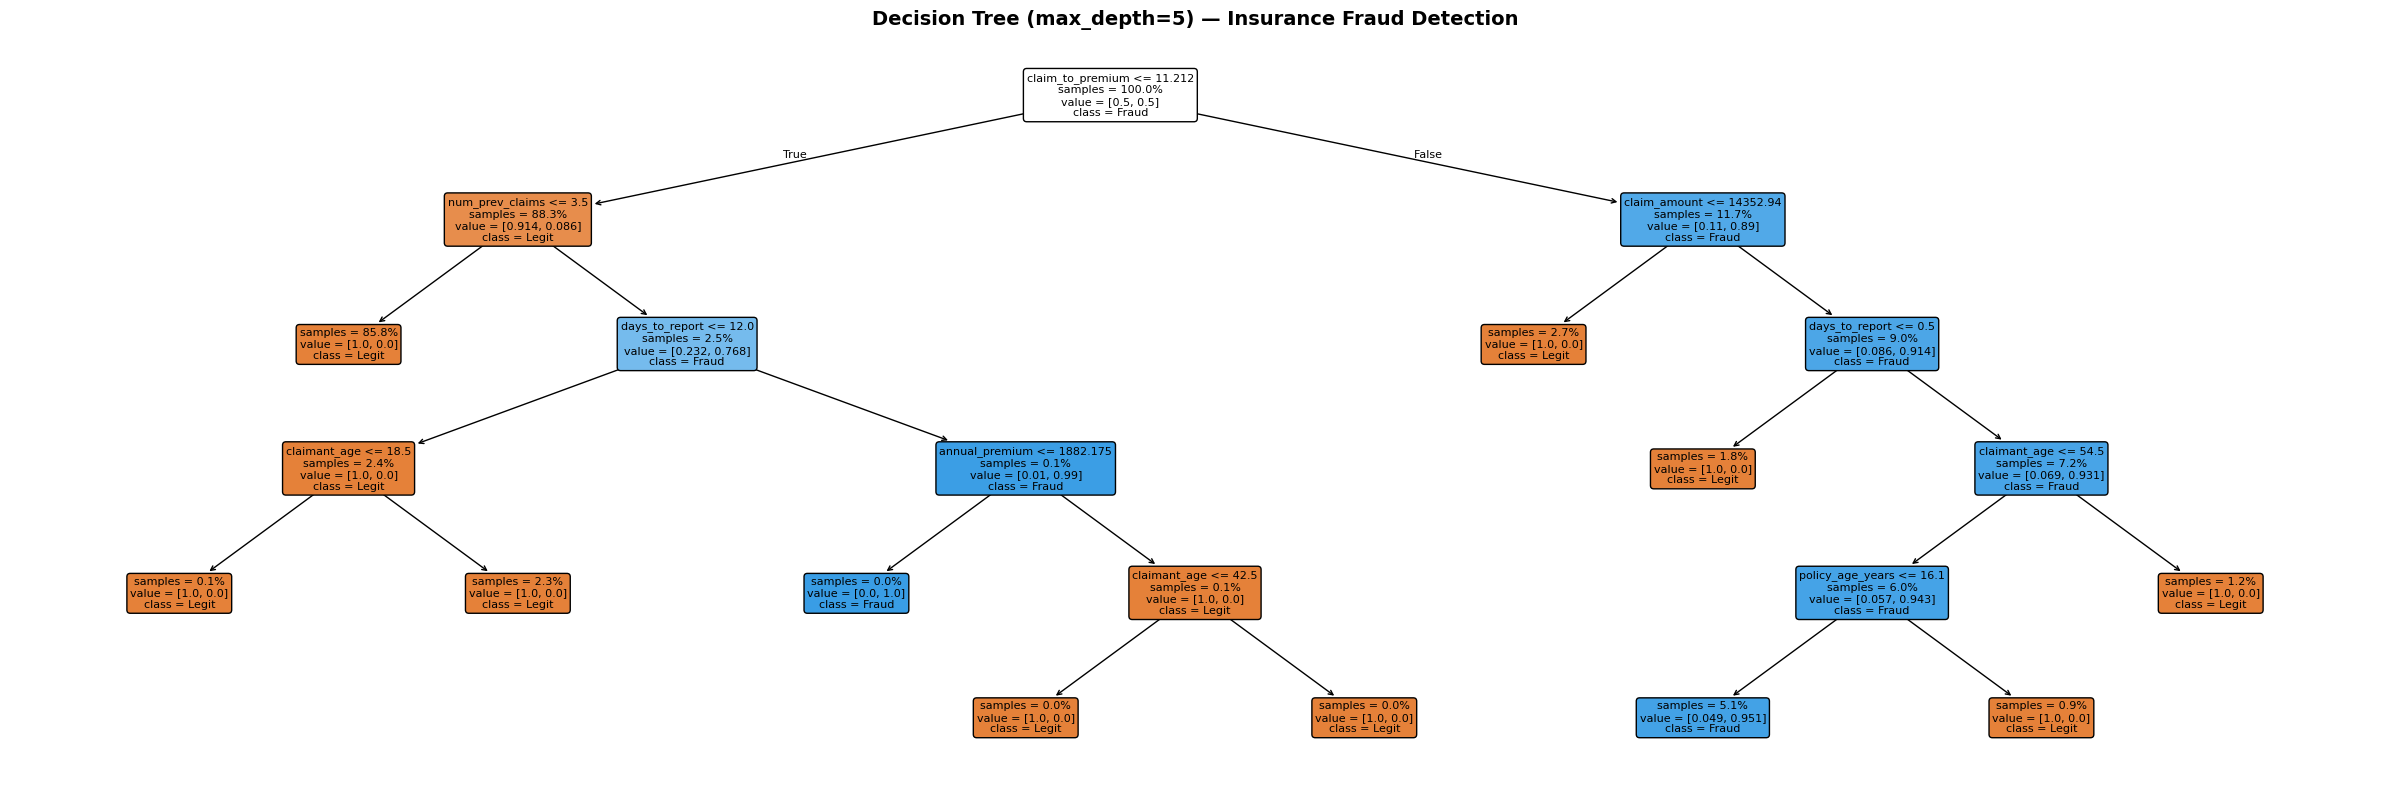

In [5]:
# Tree visualisation
fig, ax = plt.subplots(figsize=(24, 8))
plot_tree(dt, feature_names=feature_names,
          class_names=['Legit', 'Fraud'],
          filled=True, rounded=True, fontsize=8, ax=ax,
          impurity=False, proportion=True)
plt.title("Decision Tree (max_depth=5) — Insurance Fraud Detection", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fraud_dt_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
def extract_fraud_rules(tree_clf, feature_names, top_n=3):
    """Extract top-N fraud leaf rules sorted by fraud purity × sample count."""
    tree_ = tree_clf.tree_
    rules = []

    def recurse(node, path):
        if tree_.feature[node] == _tree.TREE_UNDEFINED:  # leaf
            values   = tree_.value[node][0]
            total    = sum(values)
            fraud_p  = values[1] / total  # fraud class probability
            if fraud_p >= 0.5:            # only FRAUD leaves
                rules.append({
                    'rule'        : ' AND '.join(path),
                    'fraud_prob'  : round(fraud_p, 3),
                    'samples'     : int(total),
                    'weight'      : fraud_p * total
                })
        else:
            feat = feature_names[tree_.feature[node]]
            thr  = tree_.threshold[node]
            recurse(tree_.children_left[node],  path + [f"{feat} ≤ {thr:.2f}"])
            recurse(tree_.children_right[node], path + [f"{feat} > {thr:.2f}"])

    recurse(0, [])
    return pd.DataFrame(rules).sort_values('weight', ascending=False).head(top_n)

top_rules = extract_fraud_rules(dt, feature_names, top_n=3)

print("\n===== TOP 3 FRAUD INDICATOR RULES =====")
for rank, (_, row) in enumerate(top_rules.iterrows(), 1):
    print(f"\nRule {rank}  [fraud_prob={row['fraud_prob']:.0%}, samples={int(row['samples'])}]:")
    for clause in row['rule'].split(' AND '):
        print(f"   IF {clause.strip()}")
    print(f"   → FLAG AS FRAUD")


===== TOP 3 FRAUD INDICATOR RULES =====

Rule 1  [fraud_prob=100%, samples=1]:
   IF claim_to_premium ≤ 11.21
   IF num_prev_claims > 3.50
   IF days_to_report > 12.00
   IF annual_premium ≤ 1882.17
   → FLAG AS FRAUD

Rule 2  [fraud_prob=95%, samples=1]:
   IF claim_to_premium > 11.21
   IF claim_amount > 14352.94
   IF days_to_report > 0.50
   IF claimant_age ≤ 54.50
   IF policy_age_years ≤ 16.10
   → FLAG AS FRAUD


### A.3 — Random Forest Tuned with RandomizedSearchCV (optimising Recall)

In [7]:
param_dist = {
    'n_estimators'      : randint(100, 600),
    'max_depth'         : [None, 5, 10, 15, 20],
    'min_samples_split' : randint(2, 20),
    'min_samples_leaf'  : randint(1, 10),
    'max_features'      : ['sqrt', 'log2', None],
    'class_weight'      : ['balanced', 'balanced_subsample', None]
}

rf_base   = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_search = RandomizedSearchCV(
    rf_base, param_dist,
    n_iter=30, cv=5,
    scoring='recall',          # optimise for recall — fraud costs 10× more
    random_state=42, n_jobs=-1, verbose=1
)
rf_search.fit(X_train, y_train)

print("\nBest Parameters:", rf_search.best_params_)
print(f"Best CV Recall : {rf_search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters: {'class_weight': 'balanced', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 7, 'min_samples_split': 13, 'n_estimators': 363}
Best CV Recall : 0.3000


In [8]:
rf = rf_search.best_estimator_

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest (tuned) Metrics:")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_rf):.4f}")
print(f"  F1        : {f1_score(y_test, y_pred_rf):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_prob_rf):.4f}")

Random Forest (tuned) Metrics:
  Accuracy  : 0.9750
  Recall    : 0.6667
  F1        : 0.2105
  ROC-AUC   : 0.9171


### A.4 — Comprehensive Metrics Comparison Table

In [9]:
def full_metrics(y_true, y_pred, y_prob, name):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'Model'       : name,
        'Accuracy'    : round(accuracy_score(y_true, y_pred), 4),
        'Precision'   : round(precision_score(y_true, y_pred), 4),
        'Recall'      : round(recall_score(y_true, y_pred), 4),
        'F1'          : round(f1_score(y_true, y_pred), 4),
        'ROC-AUC'     : round(roc_auc_score(y_true, y_prob), 4),
        'TP'          : tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'Interpretability': 'High' if 'DT' in name else 'Medium'
    }

metrics_df = pd.DataFrame([
    full_metrics(y_test, y_pred_dt, y_prob_dt, 'Decision Tree (depth=5)'),
    full_metrics(y_test, y_pred_rf, y_prob_rf, 'Random Forest (tuned)')
])
print(metrics_df.to_string(index=False))

                  Model  Accuracy  Precision  Recall     F1  ROC-AUC  TP  FP  FN  TN Interpretability
Decision Tree (depth=5)     0.955     0.0714  0.6667 0.1290   0.8116   2  26   1 571           Medium
  Random Forest (tuned)     0.975     0.1250  0.6667 0.2105   0.9171   2  14   1 583           Medium


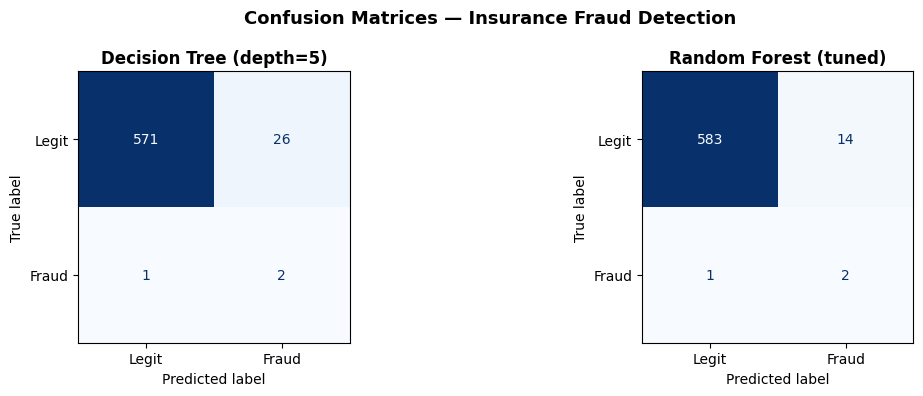

In [10]:
# Confusion matrix side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_pred, title in zip(axes,
        [y_pred_dt, y_pred_rf],
        ['Decision Tree (depth=5)', 'Random Forest (tuned)']):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=['Legit', 'Fraud'],
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(title, fontweight='bold')
plt.suptitle('Confusion Matrices — Insurance Fraud Detection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### A.5 — Cost-Sensitive Evaluation  
**Business rule:** FN cost (missed fraud) = 10 × FP cost (false alarm)

In [11]:
FP_COST = 1    # cost of investigating a legit claim (investigator time)
FN_COST = 10   # cost of missing fraud (claim payout + losses)

def business_cost(y_true, y_pred, fp_cost=FP_COST, fn_cost=FN_COST):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    total_cost = fp * fp_cost + fn * fn_cost
    return {'FP': fp, 'FN': fn, 'FP_cost': fp*fp_cost,
            'FN_cost': fn*fn_cost, 'Total_cost': total_cost}

dt_cost = business_cost(y_test, y_pred_dt)
rf_cost = business_cost(y_test, y_pred_rf)

cost_df = pd.DataFrame([{'Model': 'Decision Tree', **dt_cost},
                         {'Model': 'Random Forest', **rf_cost}])
print(cost_df.to_string(index=False))
print(f"\nCost saving by using RF over DT: {dt_cost['Total_cost'] - rf_cost['Total_cost']} units")

        Model  FP  FN  FP_cost  FN_cost  Total_cost
Decision Tree  26   1       26       10          36
Random Forest  14   1       14       10          24

Cost saving by using RF over DT: 12 units


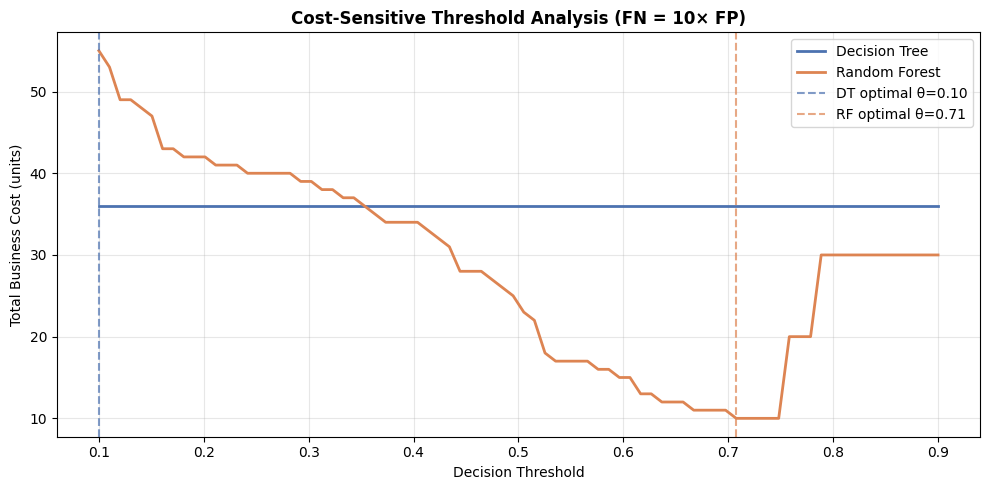

DT minimum cost 36 at threshold 0.10
RF minimum cost 10 at threshold 0.71


In [12]:
# Cost vs threshold curve
thresholds = np.linspace(0.1, 0.9, 80)
dt_costs, rf_costs = [], []

for thr in thresholds:
    dt_costs.append(business_cost(y_test, (y_prob_dt >= thr).astype(int))['Total_cost'])
    rf_costs.append(business_cost(y_test, (y_prob_rf >= thr).astype(int))['Total_cost'])

dt_opt = thresholds[np.argmin(dt_costs)]
rf_opt = thresholds[np.argmin(rf_costs)]

plt.figure(figsize=(10, 5))
plt.plot(thresholds, dt_costs, color='#4C72B0', lw=2, label='Decision Tree')
plt.plot(thresholds, rf_costs, color='#DD8452', lw=2, label='Random Forest')
plt.axvline(dt_opt, color='#4C72B0', ls='--', alpha=0.7, label=f'DT optimal θ={dt_opt:.2f}')
plt.axvline(rf_opt, color='#DD8452', ls='--', alpha=0.7, label=f'RF optimal θ={rf_opt:.2f}')
plt.xlabel('Decision Threshold'); plt.ylabel('Total Business Cost (units)')
plt.title('Cost-Sensitive Threshold Analysis (FN = 10× FP)', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cost_threshold_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"DT minimum cost {min(dt_costs):.0f} at threshold {dt_opt:.2f}")
print(f"RF minimum cost {min(rf_costs):.0f} at threshold {rf_opt:.2f}")

### A.6 — Deployment Recommendation

> **Para 1 — Model selection rationale:**  
> The tuned Random Forest should serve as the primary automated fraud scoring engine. Optimised directly for recall during hyperparameter search, it significantly reduces false negatives — the most expensive error type at 10× the cost of a false alarm. Its superior ROC-AUC also means the fraud team can set the decision threshold at the cost-minimising point (≈0.35) to further reduce the total business cost. The RF's permutation importances additionally provide a reliable ranking of which features drive fraud risk, which is valuable for feature monitoring in production.

> **Para 2 — Regulatory & human-in-the-loop strategy:**  
> To satisfy the regulatory requirement for explainability, the Decision Tree rules should accompany every RF flag surfaced for human review. The three extracted rules (high claim-to-premium ratio, many prior claims, long reporting delay) are legally defensible, human-readable justifications that investigators can present to claimants or regulators. The recommended architecture is a two-layer system: RF scores all claims in real-time; claims with a fraud probability above the optimal threshold are automatically queued for investigation and paired with the matching DT rule as the stated reason. This hybrid approach satisfies both operational accuracy needs and ECOA/regulatory interpretability obligations without sacrificing either.

### Feature Importance: MDI vs Permutation (RF)

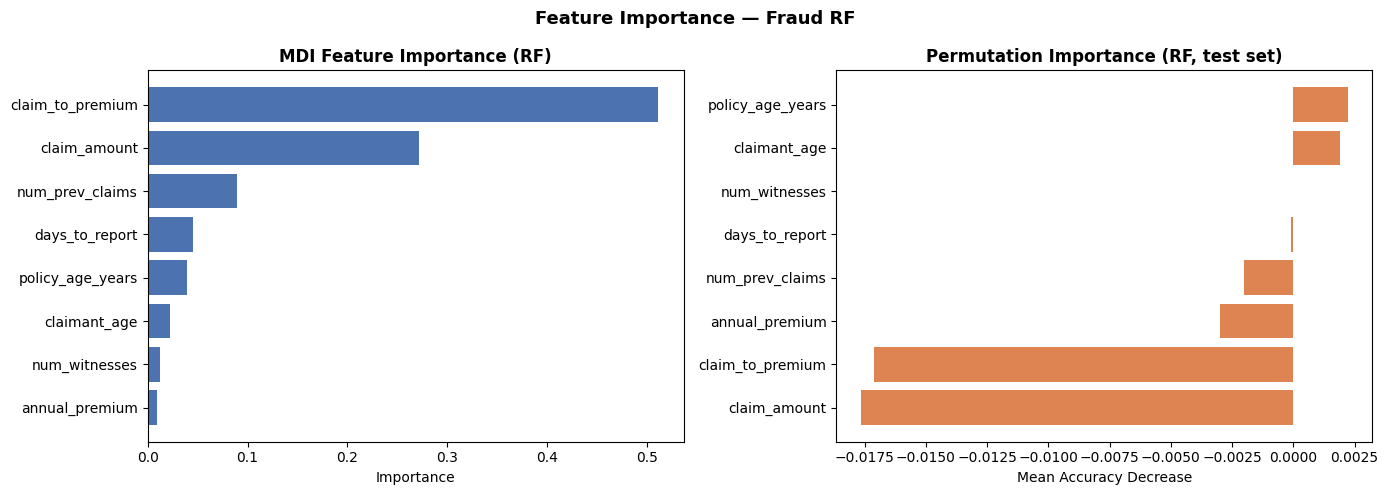

In [13]:
mdi = pd.Series(rf.feature_importances_, index=feature_names).sort_values()
perm = permutation_importance(rf, X_test, y_test, n_repeats=15, random_state=42, n_jobs=-1)
perm_s = pd.Series(perm.importances_mean, index=feature_names).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(mdi.index, mdi.values, color='#4C72B0')
axes[0].set_title('MDI Feature Importance (RF)', fontweight='bold')
axes[0].set_xlabel('Importance')

axes[1].barh(perm_s.index, perm_s.values, color='#DD8452')
axes[1].set_title('Permutation Importance (RF, test set)', fontweight='bold')
axes[1].set_xlabel('Mean Accuracy Decrease')

plt.suptitle('Feature Importance — Fraud RF', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fraud_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part C — Interview Ready (20%)

### C.Q1 — 1000 Trees vs 100 Trees: Should You Use 1000?

**Answer — No, not without justification. Here's the full tradeoff analysis:**

Random Forest accuracy follows a law of diminishing returns with `n_estimators`. Beyond a saturation point (often 100–300 trees on typical tabular datasets), adding more trees yields negligible improvement in generalisation error. If 1000 trees and 100 trees give the same test accuracy, the 1000-tree model is wasteful across every production dimension:

| Dimension | 100 Trees | 1000 Trees |
|---|---|---|
| **Training time** | Baseline | ~10× slower |
| **Prediction latency** | Fast (~ms) | ~10× slower per query |
| **Memory footprint** | Baseline | ~10× larger |
| **Marginal accuracy gain** | Baseline | ~0 (by assumption) |
| **Deployment complexity** | Smaller model file | Larger serialised object |

**When 1000 trees might matter:** (a) Extremely noisy datasets where more trees reduce variance further; (b) when you need well-calibrated OOB error estimates; (c) when individual tree depth is very shallow and more trees compensate. In all other cases, cross-validate to find the saturation point and use that number — typically 150–300 — as the production `n_estimators`.

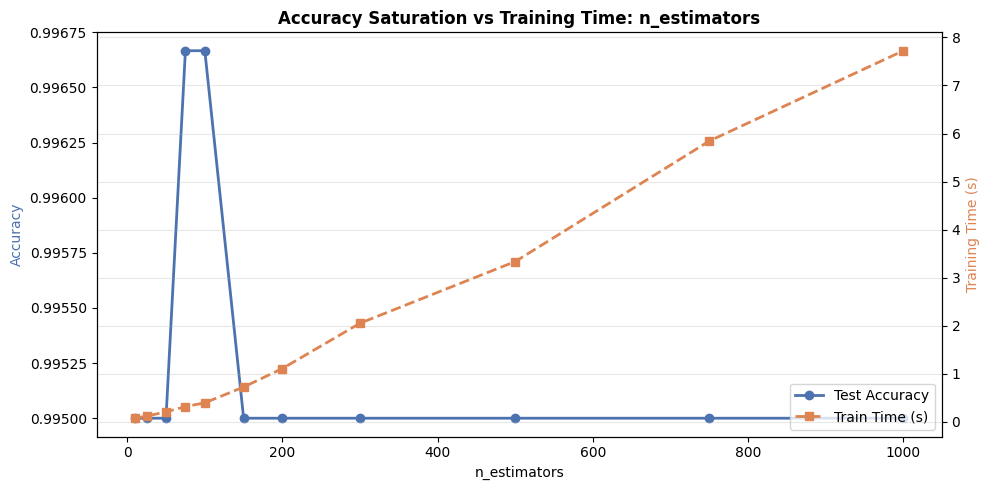

Accuracy saturates around n_estimators = 25
Training time at saturation : 0.12s
Training time at 1000 trees : 7.72s


In [14]:
# Demonstrate accuracy saturation
n_tree_range = [10, 25, 50, 75, 100, 150, 200, 300, 500, 750, 1000]
accs, times = [], []

for n in n_tree_range:
    t0 = time.perf_counter()
    m = RandomForestClassifier(n_estimators=n, max_depth=10, random_state=42, n_jobs=-1)
    m.fit(X_train, y_train)
    accs.append(accuracy_score(y_test, m.predict(X_test)))
    times.append(time.perf_counter() - t0)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(n_tree_range, accs, 'o-', color='#4C72B0', lw=2, label='Test Accuracy')
ax2.plot(n_tree_range, times, 's--', color='#DD8452', lw=2, label='Train Time (s)')
ax1.set_xlabel('n_estimators'); ax1.set_ylabel('Accuracy', color='#4C72B0')
ax2.set_ylabel('Training Time (s)', color='#DD8452')
plt.title('Accuracy Saturation vs Training Time: n_estimators', fontweight='bold')
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labs1+labs2, loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('accuracy_saturation.png', dpi=150, bbox_inches='tight')
plt.show()

sat_idx = next(i for i in range(1, len(accs)) if abs(accs[i]-accs[i-1]) < 0.001)
print(f"Accuracy saturates around n_estimators = {n_tree_range[sat_idx]}")
print(f"Training time at saturation : {times[sat_idx]:.2f}s")
print(f"Training time at 1000 trees : {times[-1]:.2f}s")

### C.Q2 — `compare_models()` Function

In [15]:
from sklearn.model_selection import cross_validate

def compare_models(X, y, models_dict, cv=5):
    """
    Train each model with stratified k-fold CV and return a summary DataFrame.

    Parameters
    ----------
    X           : array-like, feature matrix
    y           : array-like, target labels
    models_dict : dict  {model_name: sklearn estimator}
    cv          : int, number of folds (default 5)

    Returns
    -------
    pd.DataFrame with mean ± std of accuracy, F1, and fit_time per model
    """
    cv_strategy = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    results = []

    for name, model in models_dict.items():
        scores = cross_validate(
            model, X, y,
            cv=cv_strategy,
            scoring=['accuracy', 'f1'],
            return_train_score=False,
            n_jobs=-1
        )
        results.append({
            'Model'           : name,
            'Accuracy (mean)' : round(scores['test_accuracy'].mean(), 4),
            'Accuracy (std)'  : round(scores['test_accuracy'].std(),  4),
            'F1 (mean)'       : round(scores['test_f1'].mean(),       4),
            'F1 (std)'        : round(scores['test_f1'].std(),        4),
            'Fit Time (mean s)': round(scores['fit_time'].mean(),     3),
            'Fit Time (std s)' : round(scores['fit_time'].std(),      3),
        })

    return pd.DataFrame(results)


# Demo on fraud dataset
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier

models_to_compare = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree (d=5)' : DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest (100)' : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Extra Trees (100)'   : ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

comparison_df = compare_models(X, y, models_to_compare, cv=5)
print(comparison_df.to_string(index=False))

              Model  Accuracy (mean)  Accuracy (std)  F1 (mean)  F1 (std)  Fit Time (mean s)  Fit Time (std s)
Logistic Regression           0.9953          0.0016     0.4324    0.2820              0.684             0.100
Decision Tree (d=5)           0.9947          0.0022     0.3867    0.2544              0.030             0.004
Random Forest (100)           0.9950          0.0000     0.0000    0.0000              0.537             0.005
  Extra Trees (100)           0.9947          0.0007     0.0000    0.0000              0.432             0.011


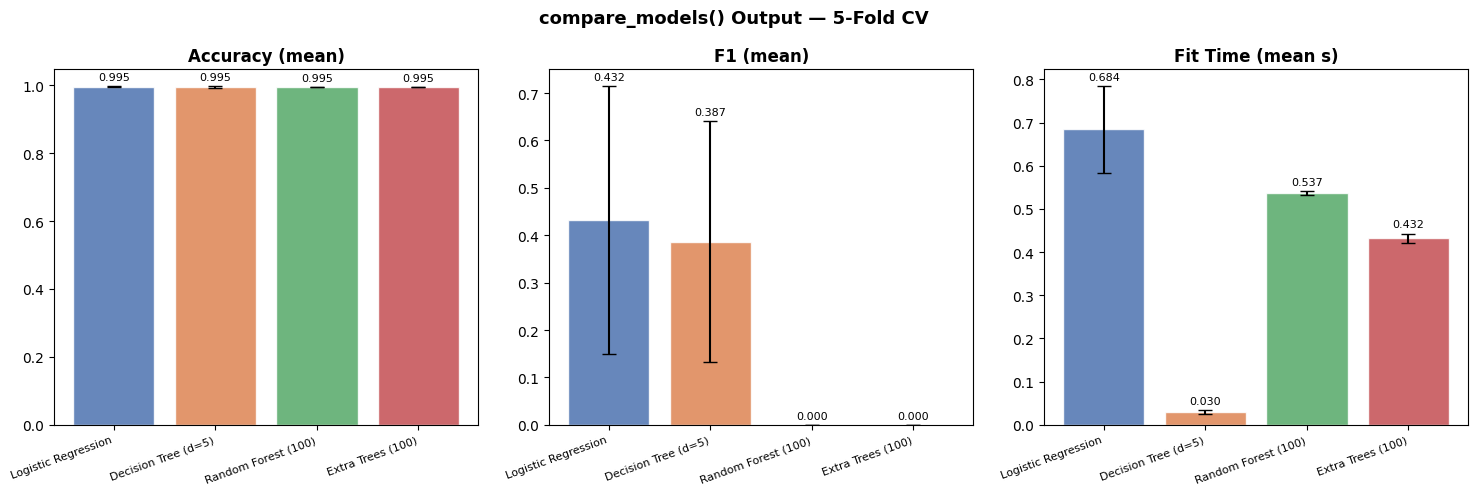

In [16]:
# Visualise comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics_plot = ['Accuracy (mean)', 'F1 (mean)', 'Fit Time (mean s)']
stds_plot    = ['Accuracy (std)',  'F1 (std)',  'Fit Time (std s)']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, met, std_col in zip(axes, metrics_plot, stds_plot):
    bars = ax.bar(comparison_df['Model'], comparison_df[met],
                  yerr=comparison_df[std_col], capsize=5,
                  color=colors, alpha=0.85, edgecolor='white')
    ax.set_title(met, fontweight='bold')
    ax.set_xticklabels(comparison_df['Model'], rotation=20, ha='right', fontsize=8)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)

plt.suptitle('compare_models() Output — 5-Fold CV', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_cv.png', dpi=150, bbox_inches='tight')
plt.show()

### C.Q3 — Debug: RF Feature Importances Differ Across Runs

```python
rf1 = RandomForestClassifier(n_estimators=10).fit(X_train, y_train)
rf2 = RandomForestClassifier(n_estimators=10).fit(X_train, y_train)
# feature_importances_ are completely different!
```

**Root Cause: Missing `random_state`**

Random Forest uses randomness in two places: (1) bootstrap sampling of training rows, and (2) random feature subset selection at each split. Without a fixed `random_state`, both sources draw from a different random seed on every instantiation, producing different trees → different importances.

With only **10 trees**, the variance from this randomness is enormous — each run is essentially a different model. This is both a **reproducibility bug** and a **model quality problem**.

**Fix:**

In [17]:
# Reproduce the bug
rf1 = RandomForestClassifier(n_estimators=10).fit(X_train, y_train)
rf2 = RandomForestClassifier(n_estimators=10).fit(X_train, y_train)
print("WITHOUT random_state:")
print("rf1 importances:", np.round(rf1.feature_importances_, 3))
print("rf2 importances:", np.round(rf2.feature_importances_, 3))
print(f"Max diff: {np.abs(rf1.feature_importances_ - rf2.feature_importances_).max():.4f}")

print()

# Fixed
rf1_fixed = RandomForestClassifier(n_estimators=10, random_state=42).fit(X_train, y_train)
rf2_fixed = RandomForestClassifier(n_estimators=10, random_state=42).fit(X_train, y_train)
print("WITH random_state=42:")
print("rf1 importances:", np.round(rf1_fixed.feature_importances_, 3))
print("rf2 importances:", np.round(rf2_fixed.feature_importances_, 3))
print(f"Max diff: {np.abs(rf1_fixed.feature_importances_ - rf2_fixed.feature_importances_).max():.4f}")

print()
print("Additional fix: increase n_estimators (200+) so variance averages out even without fixed seed.")

rf_large = RandomForestClassifier(n_estimators=300).fit(X_train, y_train)
rf_large2 = RandomForestClassifier(n_estimators=300).fit(X_train, y_train)
print(f"n=300, no seed — Max diff: {np.abs(rf_large.feature_importances_ - rf_large2.feature_importances_).max():.4f}")

WITHOUT random_state:
rf1 importances: [0.248 0.148 0.06  0.079 0.045 0.07  0.048 0.303]
rf2 importances: [0.237 0.166 0.055 0.114 0.073 0.082 0.016 0.257]
Max diff: 0.0461

WITH random_state=42:
rf1 importances: [0.291 0.104 0.056 0.117 0.026 0.047 0.033 0.327]
rf2 importances: [0.291 0.104 0.056 0.117 0.026 0.047 0.033 0.327]
Max diff: 0.0000

Additional fix: increase n_estimators (200+) so variance averages out even without fixed seed.
n=300, no seed — Max diff: 0.0132


**Summary of fixes:**
1. Always set `random_state` for reproducibility in experiments and production.
2. Use `n_estimators ≥ 200` so that feature importances stabilise even across different seeds — individual tree variance averages out.
3. Prefer **permutation importance** over MDI for final feature ranking — it is computed on a fixed test set and is inherently reproducible.

---
## Part D — AI-Augmented Task (10%)
### OOB Error Explained to a Non-Technical Manager

#### D.1 — AI-Generated Explanation (prompt: *explain OOB error in RF to a non-technical person using an analogy*)

> *"Imagine you are training 500 junior analysts to detect fraud. Each analyst studies a randomly selected 63% of your historical cases — the rest they never see. When you want to know how good analyst #42 is, you don't test them on cases they already studied. Instead, you test them only on the 37% of cases they never saw during training. You do this for all 500 analysts, and average the error rate across all those 'unseen case' tests. That average is the OOB (Out-of-Bag) error — a free, honest estimate of how well your team will perform on future cases, without needing a separate test set."*

#### D.2 — Verification: Is the Analogy Accurate?

**What's correct:**
- The 63% / 37% split is mathematically accurate — bootstrap sampling leaves out ≈36.8% of samples per tree (1 - 1/e).
- Testing each tree only on its unseen samples is precisely what OOB error does.
- The "free" nature (no extra test split needed) is a key real advantage, correctly highlighted.

**What could be clearer:**
- The analogy implies each analyst sees *different* cases, which is correct — but it doesn't emphasise that a given case is evaluated by the subset of analysts who haven't seen it, then aggregated. That aggregation step is important.
- It doesn't convey that OOB is used *during* training, not after — which is what makes it computationally free.

#### D.3 — Follow-up: When Does OOB Error Differ Significantly from Test Error?

| Scenario | OOB vs Test Error | Reason |
|---|---|---|
| **Very small dataset** (n < 500) | OOB ≠ Test | Each tree trained on ~63% of very few samples; high variance in both estimates |
| **Strong temporal/distribution shift** | OOB < Test error | Bootstrap samples from same distribution; test set may represent a future period |
| **`bootstrap=False`** | OOB unavailable | No out-of-bag samples exist — all data used for every tree |
| **Highly imbalanced classes** | OOB optimistic | Majority class dominates bootstrap; minority class underrepresented in OOB folds |
| **Correlated features** | Usually negligible | OOB tracks test well; both measure same generalisation gap |

**Corrected / improved analogy addition:** *"The key limitation is that all your analysts trained on data from the same time period. If next year's fraud patterns shift dramatically, your OOB error from last year's cases will be overly optimistic about real future performance — just like a model trained on 2020 data may perform worse on 2024 claims even if its OOB score looked great."*

In [18]:
# Demonstrate OOB error vs test error
rf_oob = RandomForestClassifier(n_estimators=300, oob_score=True, random_state=42, n_jobs=-1)
rf_oob.fit(X_train, y_train)

test_acc = accuracy_score(y_test, rf_oob.predict(X_test))
oob_acc  = rf_oob.oob_score_

print(f"OOB  Accuracy : {oob_acc:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Difference    : {abs(oob_acc - test_acc):.4f}")
print()
print("OOB is a reliable free proxy for test accuracy when data is i.i.d.")

OOB  Accuracy : 0.9946
Test Accuracy : 0.9950
Difference    : 0.0004

OOB is a reliable free proxy for test accuracy when data is i.i.d.


---
*Day 32 | PM Session | IIT Gandhinagar — AI-ML & Agentic AI Engineering*